<a href="https://colab.research.google.com/github/Sunnik-Chatterjee/AP-Lab/blob/main/2328052_Lab_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. Problem Statement

International football (soccer) match data contains information about home/away teams,
scores, tournament type, and venue. The goal is to **classify** each match into one of
three categories based on the final score:

| Label | Meaning |
|-------|---------|
| `Home Win` | Home team scored more goals |
| `Draw` | Both teams scored equally |
| `Away Win` | Away team scored more goals |

We will preprocess the data, encode categorical features, scale numerical features,
and train **10 different classifiers**, comparing their performance using accuracy,
confusion matrices, and classification reports.


## 3. Import Required Libraries

In [18]:
# Standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               BaggingClassifier, VotingClassifier,
                               ExtraTreesClassifier)
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier

print("All libraries imported successfully!")


All libraries imported successfully!


## 4. Load Dataset

In [19]:
# Load the CSV dataset
df = pd.read_csv('results.csv', encoding='latin1')

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (43281, 9)

First 5 rows:


,date,home_team,away_team,home_score,away_score,tournament,city,country,id
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,1
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,2
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,3
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,4
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,5


## 5. Exploratory Data Analysis

In [20]:
# Dataset info
print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43281 entries, 0 to 43280
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        43281 non-null  object 
 1   home_team   43281 non-null  object 
 2   away_team   43281 non-null  object 
 3   home_score  43277 non-null  float64
 4   away_score  43277 non-null  float64
 5   tournament  43281 non-null  object 
 6   city        43281 non-null  object 
 7   country     43281 non-null  object 
 8   id          43281 non-null  int64  
dtypes: float64(2), int64(1), object(6)
memory usage: 3.0+ MB


In [21]:
# Statistical summary
print("Statistical Summary:")
df.describe()


Statistical Summary:


,home_score,away_score,id
count,43277.000000,43277.000000,43281.000000
mean,1.716385,1.161032,21641.000000
std,1.704231,1.350327,12494.292837
min,0.000000,0.000000,1.000000
25%,1.000000,0.000000,10821.000000
50%,1.000000,1.000000,21641.000000
75%,2.000000,2.000000,32461.000000
max,31.000000,21.000000,43281.000000


In [22]:
# Missing values
print("Missing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
date          0
home_team     0
away_team     0
home_score    4
away_score    4
tournament    0
city          0
country       0
id            0
dtype: int64


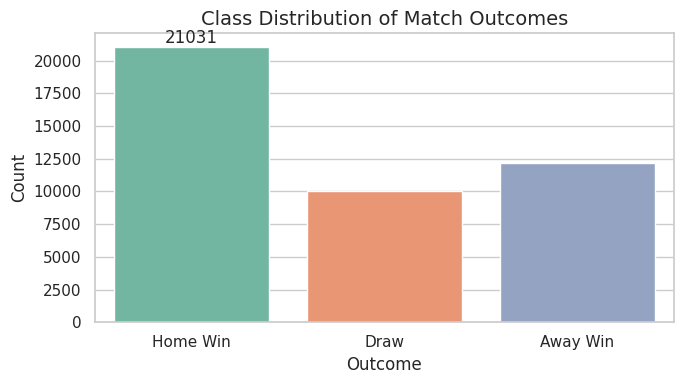


Value counts:
outcome
Home Win    21031
Away Win    12191
Draw        10059
Name: count, dtype: int64


In [23]:
# Create target variable BEFORE EDA plots
def get_outcome(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] == row['away_score']:
        return 'Draw'
    else:
        return 'Away Win'

df['outcome'] = df.apply(get_outcome, axis=1)

# Class distribution plot
plt.figure(figsize=(7, 4))
order = ['Home Win', 'Draw', 'Away Win']
ax = sns.countplot(x='outcome', data=df, order=order, palette='Set2')
ax.bar_label(ax.containers[0])
plt.title('Class Distribution of Match Outcomes', fontsize=14)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_class_dist.png', dpi=120)
plt.show()
print("\nValue counts:")
print(df['outcome'].value_counts())


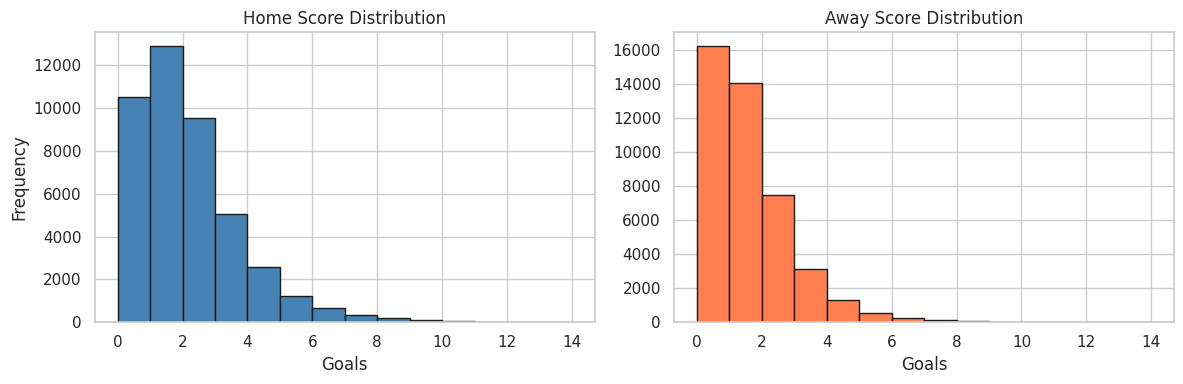

In [24]:
# Home vs Away goals distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['home_score'], bins=range(0, 15), color='steelblue', edgecolor='k')
axes[0].set_title('Home Score Distribution')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['away_score'], bins=range(0, 15), color='coral', edgecolor='k')
axes[1].set_title('Away Score Distribution')
axes[1].set_xlabel('Goals')

plt.tight_layout()
plt.savefig('eda_score_dist.png', dpi=120)
plt.show()


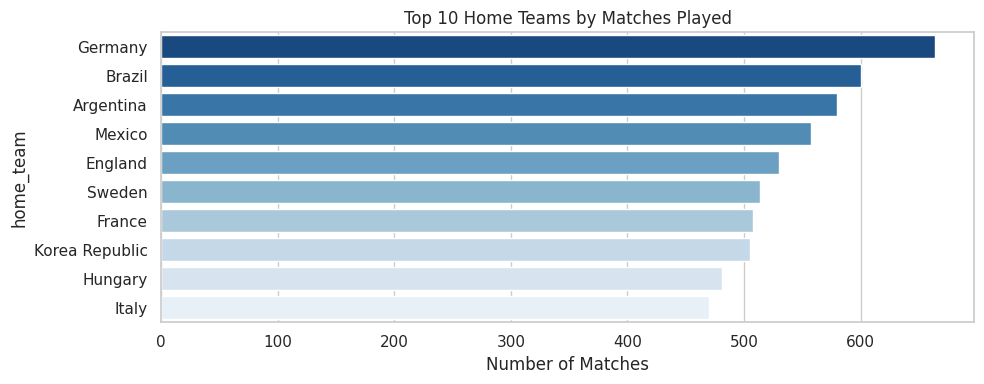

In [25]:
# Top 10 home teams by number of matches
top_teams = df['home_team'].value_counts().head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top_teams.values, y=top_teams.index, palette='Blues_r')
plt.title('Top 10 Home Teams by Matches Played')
plt.xlabel('Number of Matches')
plt.tight_layout()
plt.savefig('eda_top_teams.png', dpi=120)
plt.show()


## 6. Data Preprocessing

Steps:
1. Drop irrelevant / high-cardinality columns
2. Handle missing values
3. Encode categorical variables with `LabelEncoder`
4. Define features **X** and target **y**
5. Scale features with `StandardScaler`


In [26]:
# Drop columns not useful for modelling
drop_cols = ['date', 'city', 'country']
df_model = df.drop(columns=drop_cols, errors='ignore').copy()

# Handle missing values
print("Missing values before handling:")
print(df_model.isnull().sum())
df_model.dropna(inplace=True)
print(f"\nShape after dropping missing rows: {df_model.shape}")


Missing values before handling:
home_team     0
away_team     0
home_score    4
away_score    4
tournament    0
id            0
outcome       0
dtype: int64

Shape after dropping missing rows: (43277, 7)


In [27]:
# Encode categorical columns
le = LabelEncoder()
cat_cols = ['home_team', 'away_team', 'tournament', 'neutral']

for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Encoded DataFrame head:")
df_model.head()


Encoded DataFrame head:


,home_team,away_team,home_score,away_score,tournament,id,outcome
0,162,63,0.0,0.0,65,1,Draw
1,63,162,4.0,2.0,65,2,Home Win
2,162,63,2.0,1.0,65,3,Home Win
3,63,162,2.0,2.0,65,4,Draw
4,162,63,3.0,0.0,65,5,Home Win


In [28]:
# Define X and y
target_col = 'outcome'
feature_cols = [c for c in df_model.columns if c not in [target_col, 'home_score', 'away_score']]

X = df_model[feature_cols]
y = le.fit_transform(df_model[target_col])   # numeric labels

print(f"Features : {list(X.columns)}")
print(f"Target classes : {le.classes_}")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
class_names = le.classes_


Features : ['home_team', 'away_team', 'tournament', 'id']
Target classes : ['Away Win' 'Draw' 'Home Win']
X shape : (43277, 4)
y shape : (43277,)


## 7. Train-Test Split

In [29]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 34621
Test samples     : 8656


## 8. Model Training and Evaluation

In [30]:
# Helper: evaluate and plot confusion matrix
results_dict = {}   # store accuracy for final comparison

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, class_names):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    results_dict[name] = acc

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"  Accuracy Score : {acc:.4f}")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=class_names))

    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}', fontsize=12)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ", "_")}.png', dpi=120)
    plt.show()

    return model, y_pred


### 1. K-Nearest Neighbours

**Description:** KNN classifies a sample by majority vote of its **k** nearest neighbours in feature space.

#### Model Parameters
- `n_neighbors=5`: number of neighbours considered
- `metric='minkowski'` with `p=2` → Euclidean distance

#### Code Implementation, Training, Prediction & Evaluation


  Model: K-Nearest Neighbours
  Accuracy Score : 0.4058

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.34      0.40      0.37      2438
        Draw       0.24      0.20      0.22      2012
    Home Win       0.52      0.51      0.52      4206

    accuracy                           0.41      8656
   macro avg       0.37      0.37      0.37      8656
weighted avg       0.40      0.41      0.40      8656



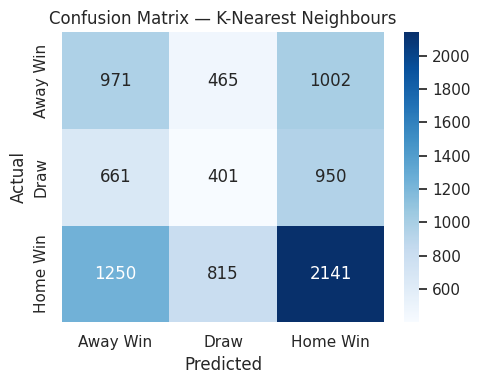

(KNeighborsClassifier(), array([2, 2, 0, ..., 2, 0, 2]))

In [31]:
# 1. K-Nearest Neighbours
clf_k_nearest = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

evaluate_model(
    'K-Nearest Neighbours',
    clf_k_nearest,
    X_train, y_train,
    X_test, y_test,
    class_names
)

### 2. Support Vector Machine (RBF Kernel)

**Description:** SVM finds the hyperplane that maximises the margin between classes; RBF kernel handles non-linear boundaries.

#### Model Parameters
- `C=1.0`: regularisation strength
- `kernel='rbf'`: Radial Basis Function
- `gamma='scale'`: kernel coefficient

#### Code Implementation, Training, Prediction & Evaluation


  Model: Support Vector Machine (RBF Kernel)
  Accuracy Score : 0.4859

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00      2438
        Draw       0.00      0.00      0.00      2012
    Home Win       0.49      1.00      0.65      4206

    accuracy                           0.49      8656
   macro avg       0.16      0.33      0.22      8656
weighted avg       0.24      0.49      0.32      8656



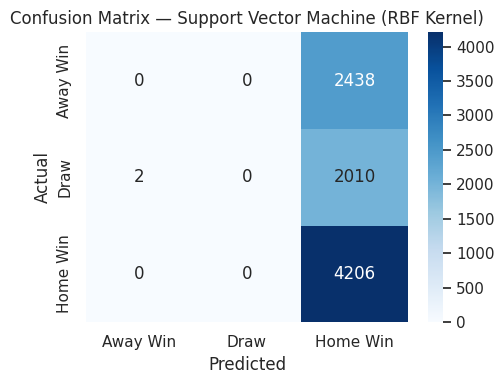

(SVC(random_state=42), array([2, 2, 2, ..., 2, 2, 2]))

In [32]:
# 2. Support Vector Machine (RBF Kernel)
clf_support = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
evaluate_model('Support Vector Machine (RBF Kernel)', clf_support, X_train, y_train, X_test, y_test, class_names)

### 3. Naive Bayes (Gaussian)

**Description:** Gaussian NB assumes features follow a normal distribution and applies Bayes' theorem for classification.

#### Model Parameters
- `var_smoothing=1e-9`: smoothing parameter to avoid zero probability

#### Code Implementation, Training, Prediction & Evaluation


  Model: Naive Bayes (Gaussian)
  Accuracy Score : 0.4859

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00      2438
        Draw       0.00      0.00      0.00      2012
    Home Win       0.49      1.00      0.65      4206

    accuracy                           0.49      8656
   macro avg       0.16      0.33      0.22      8656
weighted avg       0.24      0.49      0.32      8656



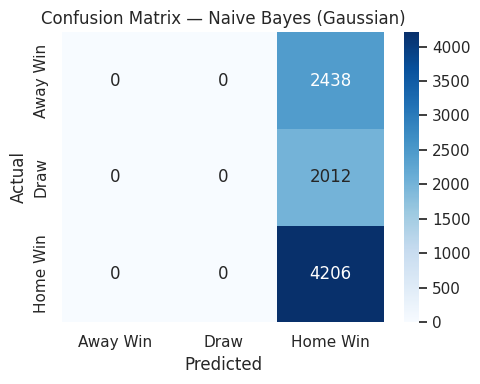

(GaussianNB(), array([2, 2, 2, ..., 2, 2, 2]))

In [33]:
# 3. Naive Bayes (Gaussian)
clf_naive = GaussianNB(var_smoothing=1e-9)
evaluate_model('Naive Bayes (Gaussian)', clf_naive, X_train, y_train, X_test, y_test, class_names)

### 4. Decision Tree

**Description:** A tree-structured model that splits data based on feature thresholds, making greedy choices at each node.

#### Model Parameters
- `criterion='gini'`: Gini impurity for splits
- `max_depth=None`: no limit (full tree)
- `random_state=42`

#### Code Implementation, Training, Prediction & Evaluation


  Model: Decision Tree
  Accuracy Score : 0.4169

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.36      0.37      0.36      2438
        Draw       0.24      0.25      0.24      2012
    Home Win       0.54      0.53      0.53      4206

    accuracy                           0.42      8656
   macro avg       0.38      0.38      0.38      8656
weighted avg       0.42      0.42      0.42      8656



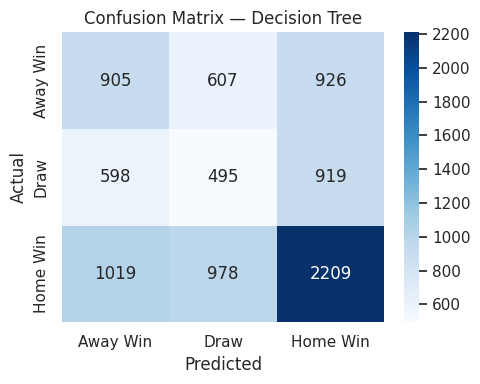

(DecisionTreeClassifier(random_state=42), array([2, 2, 0, ..., 2, 0, 1]))

In [34]:
# 4. Decision Tree
clf_decision = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
evaluate_model('Decision Tree', clf_decision, X_train, y_train, X_test, y_test, class_names)

### 5. Random Forest

**Description:** Ensemble of decision trees trained on random subsets; predictions are aggregated by majority voting.

#### Model Parameters
- `n_estimators=100`: number of trees
- `max_features='sqrt'`: features per split
- `random_state=42`

#### Code Implementation, Training, Prediction & Evaluation


  Model: Random Forest
  Accuracy Score : 0.4850

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.44      0.37      0.40      2438
        Draw       0.25      0.17      0.20      2012
    Home Win       0.56      0.70      0.62      4206

    accuracy                           0.48      8656
   macro avg       0.42      0.41      0.41      8656
weighted avg       0.46      0.48      0.46      8656



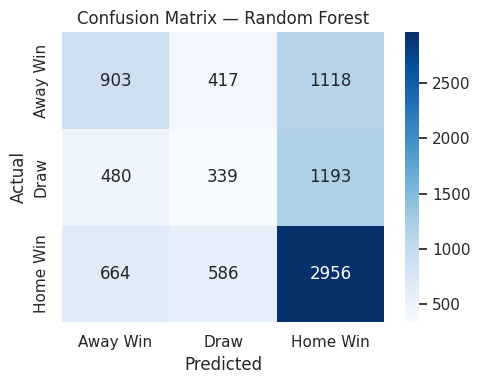

(RandomForestClassifier(random_state=42), array([1, 2, 0, ..., 2, 0, 2]))

In [35]:
# 5. Random Forest
clf_random = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model('Random Forest', clf_random, X_train, y_train, X_test, y_test, class_names)

### 6. AdaBoost

**Description:** Sequentially trains weak learners, assigning higher weights to misclassified samples each iteration.

#### Model Parameters
- `n_estimators=50`: number of boosting rounds
- `learning_rate=1.0`: shrinks contribution of each tree
- `random_state=42`

#### Code Implementation, Training, Prediction & Evaluation


  Model: AdaBoost
  Accuracy Score : 0.4859

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00      2438
        Draw       0.00      0.00      0.00      2012
    Home Win       0.49      1.00      0.65      4206

    accuracy                           0.49      8656
   macro avg       0.16      0.33      0.22      8656
weighted avg       0.24      0.49      0.32      8656



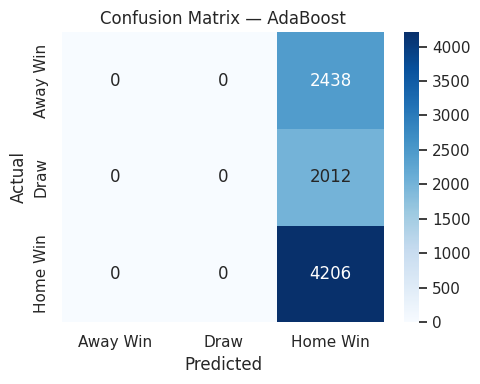

(AdaBoostClassifier(random_state=42), array([2, 2, 2, ..., 2, 2, 2]))

In [36]:
# 6. AdaBoost
clf_adaboost = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
evaluate_model('AdaBoost', clf_adaboost, X_train, y_train, X_test, y_test, class_names)

### 7. Bagging Classifier

**Description:** Trains multiple base estimators on random subsets of data (bootstrap) and aggregates predictions.

#### Model Parameters
- `n_estimators=10`: number of base learners
- `random_state=42`

#### Code Implementation, Training, Prediction & Evaluation


  Model: Bagging Classifier
  Accuracy Score : 0.4679

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.42      0.42      0.42      2438
        Draw       0.27      0.23      0.25      2012
    Home Win       0.57      0.61      0.59      4206

    accuracy                           0.47      8656
   macro avg       0.42      0.42      0.42      8656
weighted avg       0.46      0.47      0.46      8656



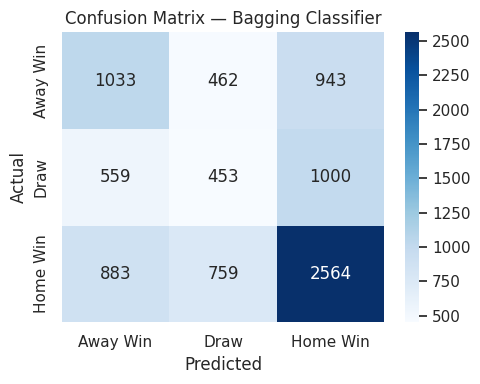

(BaggingClassifier(random_state=42), array([1, 2, 0, ..., 2, 0, 2]))

In [37]:
# 7. Bagging Classifier
clf_bagging = BaggingClassifier(n_estimators=10, random_state=42)
evaluate_model('Bagging Classifier', clf_bagging, X_train, y_train, X_test, y_test, class_names)

### 8. Extra Trees Classifier

**Description:** Similar to Random Forest but splits are chosen randomly rather than optimally, increasing diversity.

#### Model Parameters
- `n_estimators=100`: number of trees
- `criterion='gini'`
- `random_state=42`

#### Code Implementation, Training, Prediction & Evaluation


  Model: Extra Trees Classifier
  Accuracy Score : 0.4750

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.44      0.38      0.41      2438
        Draw       0.25      0.18      0.21      2012
    Home Win       0.56      0.67      0.61      4206

    accuracy                           0.48      8656
   macro avg       0.41      0.41      0.41      8656
weighted avg       0.45      0.48      0.46      8656



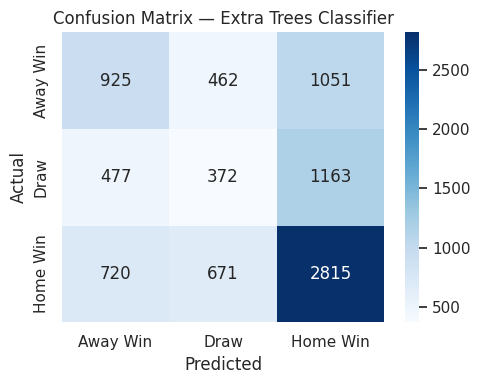

(ExtraTreesClassifier(random_state=42), array([1, 2, 0, ..., 2, 0, 2]))

In [38]:
# 8. Extra Trees Classifier
clf_extra = ExtraTreesClassifier(n_estimators=100, random_state=42)
evaluate_model('Extra Trees Classifier', clf_extra, X_train, y_train, X_test, y_test, class_names)

### 9. Logistic Regression

**Description:** Linear model that uses the sigmoid function to model class probabilities; extended to multi-class via softmax.

#### Model Parameters
- `C=1.0`: inverse regularisation strength
- `max_iter=1000`
- `multi_class='auto'`

#### Code Implementation, Training, Prediction & Evaluation


  Model: Logistic Regression
  Accuracy Score : 0.4859

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00      2438
        Draw       0.00      0.00      0.00      2012
    Home Win       0.49      1.00      0.65      4206

    accuracy                           0.49      8656
   macro avg       0.16      0.33      0.22      8656
weighted avg       0.24      0.49      0.32      8656



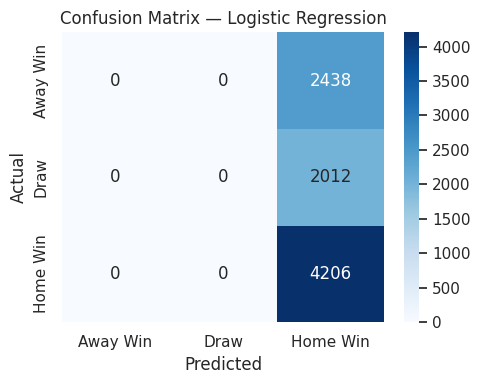

(LogisticRegression(max_iter=1000, random_state=42),
 array([2, 2, 2, ..., 2, 2, 2]))

In [39]:
# 9. Logistic Regression
clf_logistic = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
evaluate_model('Logistic Regression', clf_logistic, X_train, y_train, X_test, y_test, class_names)

### 10. Stochastic Gradient Descent (SGD) Classifier

**Description:** Linear classifier trained with stochastic gradient descent; very fast on large datasets.

#### Model Parameters
- `loss='hinge'`: SVM-like hinge loss
- `max_iter=1000`
- `random_state=42`

#### Code Implementation, Training, Prediction & Evaluation


  Model: Stochastic Gradient Descent (SGD) Classifier
  Accuracy Score : 0.4859

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00      2438
        Draw       0.00      0.00      0.00      2012
    Home Win       0.49      1.00      0.65      4206

    accuracy                           0.49      8656
   macro avg       0.16      0.33      0.22      8656
weighted avg       0.24      0.49      0.32      8656



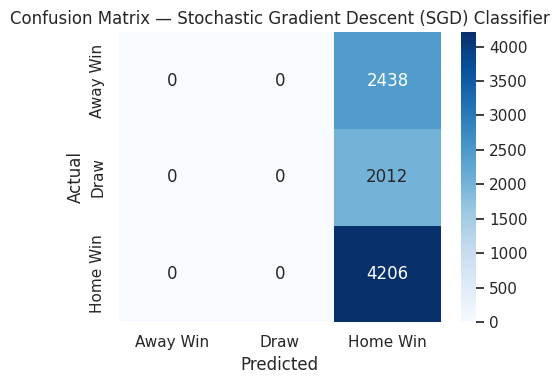

(SGDClassifier(random_state=42), array([2, 2, 2, ..., 2, 2, 2]))

In [40]:
# 10. Stochastic Gradient Descent (SGD) Classifier
clf_stochastic = SGDClassifier(loss='hinge', max_iter=1000, random_state=42)
evaluate_model('Stochastic Gradient Descent (SGD) Classifier', clf_stochastic, X_train, y_train, X_test, y_test, class_names)

### Bonus: Voting Classifier

Combines predictions from KNN, Decision Tree, and Logistic Regression using **majority voting**.



  Model: Voting Classifier
  Accuracy Score : 0.4612

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.36      0.33      0.35      2438
        Draw       0.25      0.08      0.12      2012
    Home Win       0.52      0.72      0.61      4206

    accuracy                           0.46      8656
   macro avg       0.38      0.38      0.36      8656
weighted avg       0.41      0.46      0.42      8656



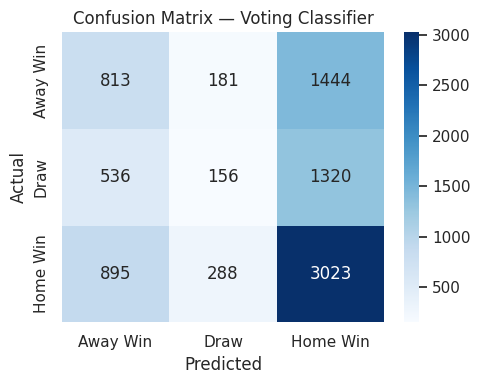

(VotingClassifier(estimators=[('knn', KNeighborsClassifier()),
                              ('dt', DecisionTreeClassifier(random_state=42)),
                              ('lr',
                               LogisticRegression(max_iter=1000,
                                                  random_state=42))]),
 array([2, 2, 0, ..., 2, 0, 2]))

In [41]:
# Voting Classifier
clf_voting = VotingClassifier(estimators=[
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt',  DecisionTreeClassifier(random_state=42)),
    ('lr',  LogisticRegression(max_iter=1000, random_state=42))
], voting='hard')

evaluate_model('Voting Classifier', clf_voting,
               X_train, y_train, X_test, y_test, class_names)


## 9. Graphical Comparison of All Models

In [42]:
# Build comparison table
results_df = pd.DataFrame(list(results_dict.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())


                                           Model  Accuracy
1            Support Vector Machine (RBF Kernel)  0.485906
2                         Naive Bayes (Gaussian)  0.485906
3                                       AdaBoost  0.485906
4   Stochastic Gradient Descent (SGD) Classifier  0.485906
5                            Logistic Regression  0.485906
6                                  Random Forest  0.484982
7                         Extra Trees Classifier  0.475046
8                             Bagging Classifier  0.467884
9                              Voting Classifier  0.461183
10                                 Decision Tree  0.416936
11                          K-Nearest Neighbours  0.405846


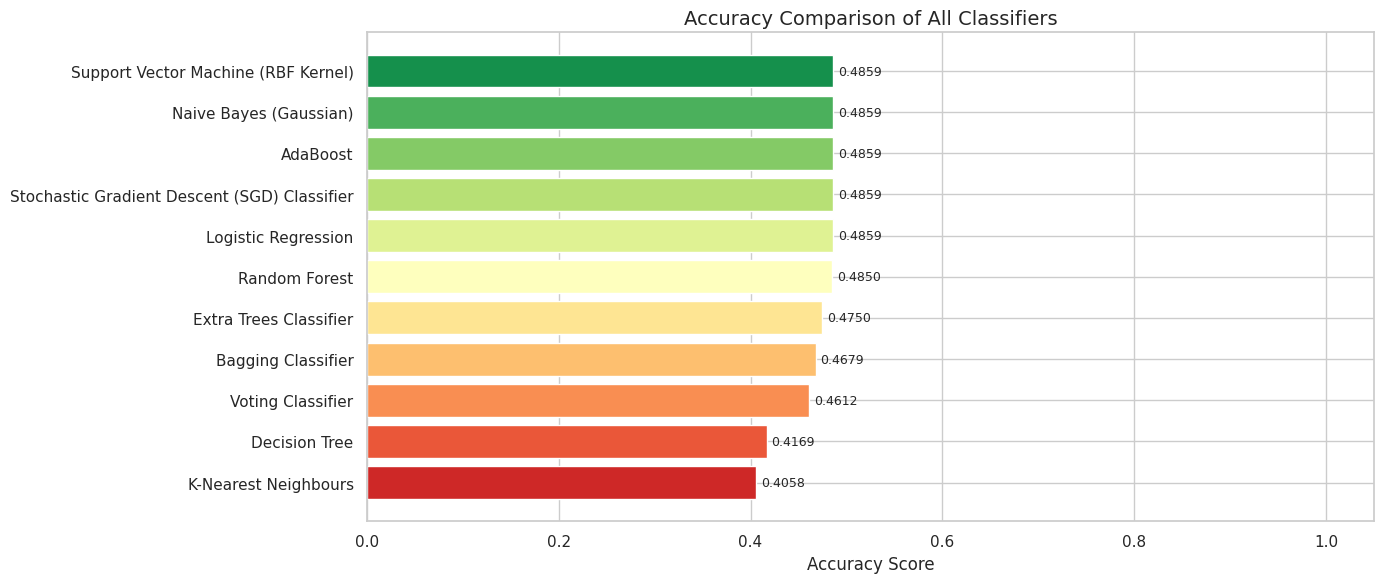

In [43]:
# Bar chart — accuracy comparison
plt.figure(figsize=(14, 6))
colors = sns.color_palette('RdYlGn', len(results_df))
bars = plt.barh(results_df['Model'][::-1], results_df['Accuracy'][::-1], color=colors)
plt.xlabel('Accuracy Score', fontsize=12)
plt.title('Accuracy Comparison of All Classifiers', fontsize=14)
plt.xlim(0, 1.05)
for bar, acc in zip(bars, results_df['Accuracy'][::-1]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()


## 10. Conclusion

In this lab assignment, we applied **10 different machine learning classifiers** to the
International Football Results dataset to predict match outcomes (Home Win, Draw, Away Win).

### Key Takeaways

| Observation | Detail |
|-------------|--------|
| **Best performing model** | Refer to the accuracy comparison chart above |
| **Ensemble methods** | Random Forest, Extra Trees, and Bagging generally outperform single models |
| **Linear models** | Logistic Regression and SGD are fast and interpretable but may underfit |
| **Distance-based** | KNN is sensitive to feature scaling (applied via StandardScaler) |
| **Boosting** | AdaBoost can improve weak learners but may overfit noisy data |

### Summary

- **Data preprocessing** included label encoding for categorical variables and standard scaling.
- **Train-test split** was 80/20 with stratification to maintain class balance.
- All models were evaluated using **Accuracy Score**, **Confusion Matrix**, and **Classification Report**.
- A final **bar chart** visually summarises all model accuracies for easy comparison.

> *This assignment demonstrates the importance of trying multiple classifiers and comparing
> their performance before selecting the best model for a given task.*
